In [1]:
# Cell 1 — Setup: install LightGBM if needed, imports, paths
import importlib.util
if importlib.util.find_spec("lightgbm") is None:
    !pip install lightgbm --quiet

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from models.utils import (
    chronological_split,
    select_enhanced_features,
    TARGET_REG,
    TARGET_CLASS,
    regression_report,
    classification_report,
    apply_feature_transforms,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

FEATURES = PROJECT_ROOT / "data" / "features"


In [2]:
# Cell 2 — Load feature matrix, chronological split, feature list
mat = pd.read_parquet(FEATURES / "feature_matrix_engineered_v2.parquet")
mat = apply_feature_transforms(mat)
train, val, test = chronological_split(mat)

features = select_enhanced_features(mat)
print(f"\n{len(features)} features selected")
print("First 10:", features[:10], "...")
print("Last 10: ", features[-10:])


  Split boundaries:
    Train: 2016-01-31 06:00:00+00:00 → 2022-12-31 23:00:00+00:00 (60,429 rows)
    Val:   2023-01-01 00:00:00+00:00 → 2023-12-31 23:00:00+00:00 (8,760 rows)
    Test:  2024-01-01 00:00:00+00:00 → 2024-12-31 06:00:00+00:00 (8,767 rows)

87 features selected
First 10: ['Houston_cloud_cover', 'Houston_precipitation', 'Houston_relative_humidity_2m', 'Houston_temperature_2m', 'Houston_wind_gusts_10m', 'Houston_wind_speed_10m', 'North (Dallas)_cloud_cover', 'North (Dallas)_precipitation', 'North (Dallas)_relative_humidity_2m', 'North (Dallas)_temperature_2m'] ...
Last 10:  ['stress_gas_spike', 'stress_heat_wave', 'stress_low_wind', 'stress_reactor_outage', 'stress_score', 'temp_max_across_zones', 'temp_min_across_zones', 'temp_range_across_zones', 'wind_mean_across_zones', 'wind_min_across_zones']


In [3]:
# Cell 3 — Shared model arrays for regression and classification
df_reg = mat.dropna(subset=[TARGET_REG])
tr_reg, vl_reg, te_reg = chronological_split(df_reg)

X_train_r = tr_reg[features].ffill().fillna(0);  y_train_r = tr_reg[TARGET_REG]
X_val_r   = vl_reg[features].ffill().fillna(0);  y_val_r   = vl_reg[TARGET_REG]
X_test_r  = te_reg[features].ffill().fillna(0);  y_test_r  = te_reg[TARGET_REG]

df_clf = mat.dropna(subset=[TARGET_CLASS])
tr_clf, vl_clf, te_clf = chronological_split(df_clf)

X_train_c = tr_clf[features].ffill().fillna(0);  y_train_c = tr_clf[TARGET_CLASS]
X_val_c   = vl_clf[features].ffill().fillna(0);  y_val_c   = vl_clf[TARGET_CLASS]
X_test_c  = te_clf[features].ffill().fillna(0);  y_test_c  = te_clf[TARGET_CLASS]

print(f"Regression arrays:     X_train={X_train_r.shape}, X_val={X_val_r.shape}, X_test={X_test_r.shape}")
print(f"Classification arrays: X_train={X_train_c.shape}, X_val={X_val_c.shape}, X_test={X_test_c.shape}")


  Split boundaries:
    Train: 2016-01-31 06:00:00+00:00 → 2022-12-31 23:00:00+00:00 (60,428 rows)
    Val:   2023-01-01 00:00:00+00:00 → 2023-12-31 23:00:00+00:00 (8,760 rows)
    Test:  2024-01-01 00:00:00+00:00 → 2024-12-31 06:00:00+00:00 (8,767 rows)
  Split boundaries:
    Train: 2016-01-31 06:00:00+00:00 → 2022-12-31 23:00:00+00:00 (60,429 rows)
    Val:   2023-01-01 00:00:00+00:00 → 2023-12-31 23:00:00+00:00 (8,760 rows)
    Test:  2024-01-01 00:00:00+00:00 → 2024-12-31 06:00:00+00:00 (8,767 rows)


Regression arrays:     X_train=(60428, 87), X_val=(8760, 87), X_test=(8767, 87)
Classification arrays: X_train=(60429, 87), X_val=(8760, 87), X_test=(8767, 87)


In [4]:
# Cell 4 — LightGBM Regressor (HB_HUBAVG)
# Hyperparameters same as XGBoost
reg = lgb.LGBMRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
)
reg.fit(
    X_train_r,
    y_train_r,
    eval_set=[(X_val_r, y_val_r)],
    callbacks=[lgb.early_stopping(25)],
)

y_pred_test_r = reg.predict(X_test_r)
print("\nTest-set metrics:")
reg_report = regression_report(y_test_r.values, y_pred_test_r, name="lightgbm_enhanced_v2_regressor test")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008025 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14739
[LightGBM] [Info] Number of data points in the train set: 60428, number of used features: 87
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 58.543587
Training until validation scores don't improve for 25 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[34]	valid_0's l2: 39024.4

Test-set metrics:

--- Regression report: lightgbm_enhanced_v2_regressor test ---
  MAE:             $19.76/MWh
  RMSE:            $100.41/MWh
  Spike recall:    34.21%
  Spike precision: 45.35%
---------------------------------



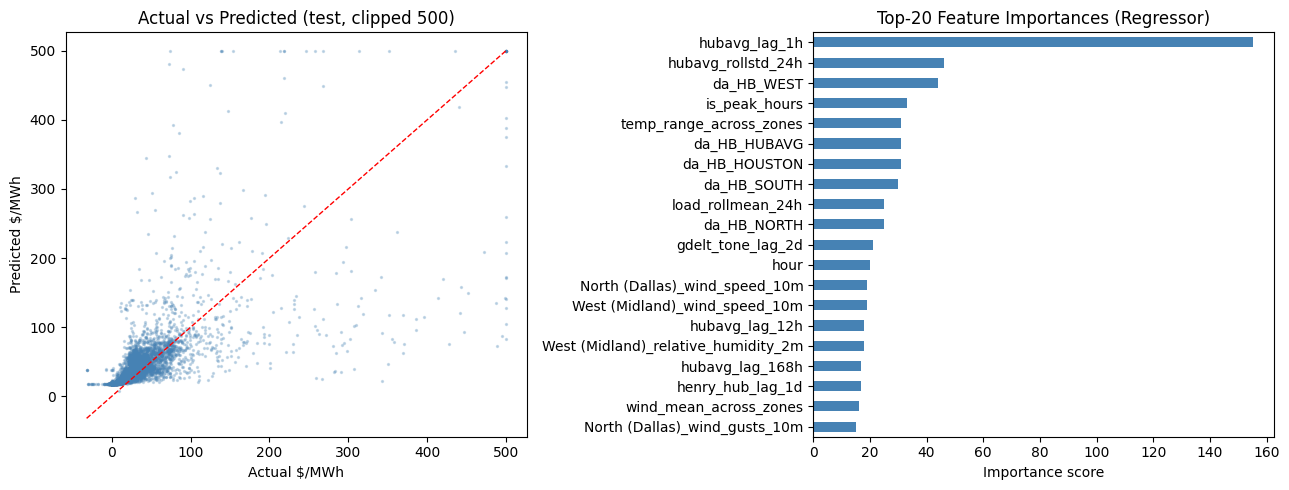

In [5]:
# Cell 5 — Regressor plots: actual vs predicted and top-20 feature importance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

clip_hi = 500
axes[0].scatter(
    y_test_r.clip(-50, clip_hi),
    np.clip(y_pred_test_r, -50, clip_hi),
    s=2,
    alpha=0.25,
    color="steelblue",
)
lo = min(y_test_r.clip(-50, clip_hi).min(), np.clip(y_pred_test_r, -50, clip_hi).min())
hi = max(y_test_r.clip(-50, clip_hi).max(), np.clip(y_pred_test_r, -50, clip_hi).max())
axes[0].plot([lo, hi], [lo, hi], "r--", lw=1)
axes[0].set_title("Actual vs Predicted (test, clipped 500)")
axes[0].set_xlabel("Actual $/MWh")
axes[0].set_ylabel("Predicted $/MWh")

reg_importance = pd.Series(reg.feature_importances_, index=features).sort_values(ascending=False)
reg_importance.head(20).sort_values().plot.barh(ax=axes[1], color="steelblue")
axes[1].set_title("Top-20 Feature Importances (Regressor)")
axes[1].set_xlabel("Importance score")

plt.tight_layout()
plt.show()


In [6]:
# Cell 6 — LightGBM Classifier (future_spike_24h)
# Hyperparameters translated from models/train_all_v2.py _train_classifier()
clf = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    n_jobs=-1,
    random_state=42,
)
clf.fit(
    X_train_c,
    y_train_c,
    eval_set=[(X_val_c, y_val_c)],
    callbacks=[lgb.early_stopping(25)],
)

val_proba = clf.predict_proba(X_val_c)[:, 1]
test_proba = clf.predict_proba(X_test_c)[:, 1]

print("\nValidation metrics:")
val_report = classification_report(y_val_c.values, val_proba, name="lightgbm_enhanced_v2_classifier val", threshold=0.5)

print("\nThreshold sweep on test set:")
threshold_reports = {}
for threshold in [0.3, 0.4, 0.5, 0.6]:
    threshold_reports[threshold] = classification_report(
        y_test_c.values,
        test_proba,
        name=f"lightgbm_enhanced_v2_classifier test@{threshold}",
        threshold=threshold,
    )


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 14827, number of negative: 45602
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005088 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14739
[LightGBM] [Info] Number of data points in the train set: 60429, number of used features: 87
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.245362 -> initscore=-1.123502
[LightGBM] [Info] Start training from score -1.123502
Training until validation scores don't improve for 25 rounds


Early stopping, best iteration is:
[9]	valid_0's binary_logloss: 0.587811

Validation metrics:

--- Classification report: lightgbm_enhanced_v2_classifier val ---
  PR-AUC:    0.524
  ROC-AUC:   0.657
  Recall:    0.00%  (at threshold 0.5)
  Precision: 0.00%
  Confusion: TP=0  FP=0  FN=2560  TN=6200
-------------------------------------


Threshold sweep on test set:

--- Classification report: lightgbm_enhanced_v2_classifier test@0.3 ---
  PR-AUC:    0.231
  ROC-AUC:   0.593
  Recall:    72.72%  (at threshold 0.3)
  Precision: 18.99%
  Confusion: TP=1069  FP=4559  FN=401  TN=2738
-------------------------------------


--- Classification report: lightgbm_enhanced_v2_classifier test@0.4 ---
  PR-AUC:    0.231
  ROC-AUC:   0.593
  Recall:    10.14%  (at threshold 0.4)
  Precision: 29.80%
  Confusion: TP=149  FP=351  FN=1321  TN=6946
-------------------------------------


--- Classification report: lightgbm_enhanced_v2_classifier test@0.5 ---
  PR-AUC:    0.231
  ROC-AUC:   0.593
  Reca

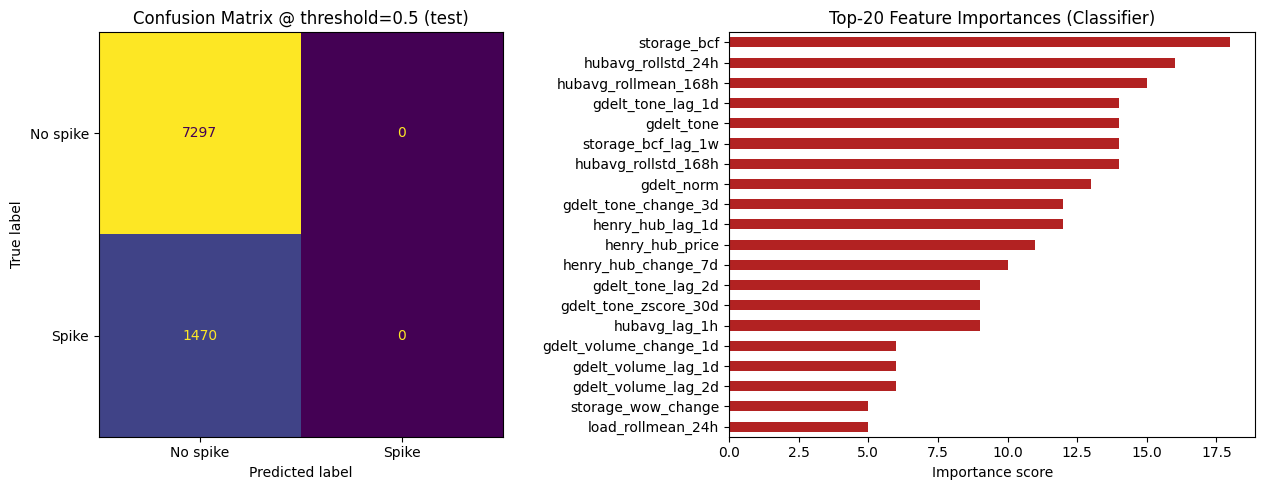

In [7]:
# Cell 7 — Classifier plots: confusion matrix at 0.5 and top-20 feature importance
cm = confusion_matrix(y_test_c, (test_proba >= 0.5).astype(int), labels=[0, 1])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm, display_labels=["No spike", "Spike"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix @ threshold=0.5 (test)")

clf_importance = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False)
clf_importance.head(20).sort_values().plot.barh(ax=axes[1], color="firebrick")
axes[1].set_title("Top-20 Feature Importances (Classifier)")
axes[1].set_xlabel("Importance score")

plt.tight_layout()
plt.show()


In [8]:
# Cell 8 — Probability distribution spot-check
qs = np.quantile(test_proba, [0, 0.25, 0.5, 0.75, 1.0])
print("Test-set probability distribution:")
print(f"  min={qs[0]:.3f}  Q1={qs[1]:.3f}  median={qs[2]:.3f}  Q3={qs[3]:.3f}  max={qs[4]:.3f}")


Test-set probability distribution:
  min=0.202  Q1=0.282  median=0.321  Q3=0.358  max=0.489


In [9]:
from sklearn.metrics import average_precision_score
import numpy as np
_y_true_dollar = np.asarray(y_test_r).reshape(-1)
_y_pred_dollar = np.asarray(y_pred_test_r).reshape(-1)
_spike_pr_auc = average_precision_score(
    (_y_true_dollar > 200).astype(int),
    _y_pred_dollar,
)
print(f"\n=== Bake-off PR-AUC (regressor-as-score, threshold $200) ===")
print(f"  Spike PR-AUC: {_spike_pr_auc:.3f}")


=== Bake-off PR-AUC (regressor-as-score, threshold $200) ===
  Spike PR-AUC: 0.427
